In [191]:
%matplotlib ipympl
from IPython.display import Image as IImage
from IPython.display import HTML, Video
from random import random
from PIL import Image
import plotly.graph_objects as go
from shapely.geometry import MultiPolygon, GeometryCollection, Polygon, LineString, Point
from shapely.affinity import rotate
from panda3d.core import Triangulator
from matplotlib import pyplot as plt
import matplotlib.animation
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.image as mpimg
import numpy as np
from descartes import PolygonPatch
import os
import sys

root_path = '../'
sys.path.append(root_path)

from src.polygon_utils import draw_multipolygon, extractpoints, mytriangulate, findpointid, ptinlist, trianglestofaces

In [ ]:
from src.config import Scanner3dConfig
if __name__ == '__main__':
    config = Scanner3dConfig()

In [193]:
def load_images(folder_path):
    # Image format : 00001.png
    images = [None for i in range(30)]
    for filename in os.listdir(folder_path):
        if filename.endswith(".png"):
            img_path = os.path.join(folder_path, filename)
            img = Image.open(img_path).convert("L")  # Converts to grayscale
            images[int(filename[:5])-1] = img
    return images

if __name__ == '__main__':
    images = load_images(os.path.join(root_path, config.input_folder))

Here we import the shadows of the object at different angles going from 0 to PI.

In [194]:
# Boolean operations with MultiPolygons

def union_multipoly(listmpoly):
    if len(listmpoly) == 0:
        return MultiPolygon()
    else:
        res = listmpoly[0]
        for mpoly in listmpoly:
            res = res.union(mpoly)
        return res

def intersection_multipoly(listmpoly):
    if len(listmpoly) == 0:
        raise ValueError("Intersection vide")
    else:
        res = listmpoly[0]
        for mpoly in listmpoly:
            res = res.intersection(mpoly)
        if isinstance(res, Polygon):
            return MultiPolygon([res])
        elif isinstance(res, MultiPolygon):
            return res
        else:
            print(res)
            return res

In [195]:
# For a given value of y, gives the list of the shadows of the layer at that
# height rotated at their corresponding angle
def processLayer(images, layer: int):
    longdistance = 3000
    multipolystointer = []
    for i in range(0, len(images), 1):
        # Computes the shadow of the layer i in the image of the shadoow at
        # angle i*180/30 in degrees
        polytounion = []
        points = []
        for x in range(-1, config.width):
            a = False if (x == -1) else images[i].getpixel((x, layer)) <= 120
            b = False if (x >= config.width - 1) else images[i].getpixel((x + 1, layer)) <= 120
            if (not (a) and b):
                points.append((x+1-config.width/2, longdistance))
                points.append((x+1-config.width/2, -longdistance))
            if (a and not (b)):
                points.append((x+1-config.width/2, -longdistance))
                points.append((x+1-config.width/2, longdistance))
                thepoly = rotate(Polygon(points), angle=i * 180 / 30, origin=(0,0))
                polytounion.append(thepoly)
                points = []
        multipolystointer.append(union_multipoly(polytounion))
    return multipolystointer

We will observe what happens at the layer y=60 the understand how we process the slice of our object from the shadows at that height

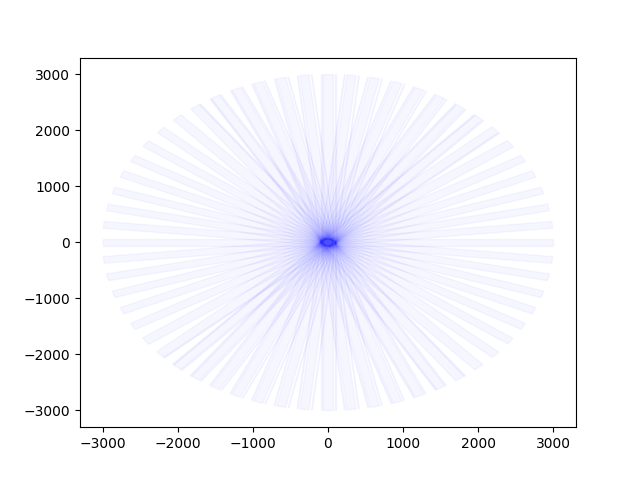

In [196]:
if __name__ == '__main__':
    layer60 = processLayer(images, 60)
    fig1, ax1 = plt.subplots()
    for mpoly in layer60:
        draw_multipolygon(mpoly, ax1, alpha=1/config.nb_images)
    plt.show()

Here you can see all the shadows at different angles of the layer y=60, you can zoom on one shadow to observe its shape and you can zoom in the middle to observe the intersection of the shadows and you can see that it looks like a cross section of our object at layer y=60.

Now let's process the intersection of those shadows at each layer, we get a slice of our object at every height

In [197]:
def get_global_bounds(multipolygons):
    """Compute the global bounding box for all multipolygons."""
    min_x = min(p.bounds[0] for mp in multipolygons for p in mp.geoms)
    min_y = min(p.bounds[1] for mp in multipolygons for p in mp.geoms)
    max_x = max(p.bounds[2] for mp in multipolygons for p in mp.geoms)
    max_y = max(p.bounds[3] for mp in multipolygons for p in mp.geoms)
    return min_x, min_y, max_x, max_y

In [ ]:
def getLayers(config, images):
    return [intersection_multipoly(processLayer(images, i)) for i in range(config.height)]

150


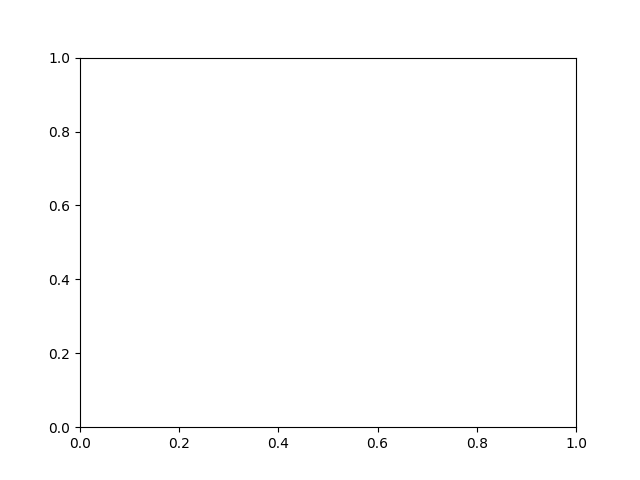

In [ ]:
if __name__ == '__main__':
    
    multipolygons = getLayers(config, images)
    print(len(multipolygons))

    plt.rcParams["animation.html"] = "jshtml"
    plt.rcParams['figure.dpi'] = 100 
    fig2, ax2 = plt.subplots()

    global_min_x, global_min_y, global_max_x, global_max_y = get_global_bounds(multipolygons)

    def animate(frame):
        ax2.clear()
        draw_multipolygon(multipolygons[frame], ax2, alpha=1)
        ax2.set_xlim(global_min_x, global_max_x)
        ax2.set_ylim(global_min_y, global_max_y)

    anim = matplotlib.animation.FuncAnimation(fig2, animate, frames=len(multipolygons))
    plt.show()


Now let's make a mesh out of those slices

In [199]:
class MyMesh:
    def __init__(self):
        self.vertices = []
        self.faces = []
        self.vertexID = 0

    def addVertex(self, pt):
        self.vertices.append(pt)
        self.vertexID += 1
        return self.vertexID - 1

    def addRectangle(self, aID, bID, cID, dID):
        self.faces += [(aID, bID, cID), (cID, dID, aID)]

    def addFaceToFace(self, ids1, ids2, multipol, reverse=False):
        if (isinstance(multipol, Polygon)):
            n = len(multipol.exterior.coords)
            for i in range(n):
                pt1 = multipol.exterior.coords[i]
                pt2 = multipol.exterior.coords[(i+1)%n]
                a = findpointid(ids1, pt2)
                b = findpointid(ids1, pt1)
                c = findpointid(ids2, pt1)
                d = findpointid(ids2, pt2)
                if (reverse):
                    self.addRectangle(d, c, b, a)
                else:
                    self.addRectangle(a, b, c, d)
            for interior in multipol.interiors:
                self.addFaceToFace(ids1, ids2, interior, reverse=True)
        elif (isinstance(multipol, MultiPolygon)):
            for pol in multipol.geoms:
                self.addFaceToFace(ids1, ids2, pol)

    def setpointsheight(self, pointidx, height):
        for ptid in pointidx:
            v = self.vertices[ptid]
            self.vertices[ptid] = (v[0], height, v[1])

    def addFace(self, f):
        self.faces.append(f)

    def plot(self):
        
        x, y, z = np.array(self.vertices).T
        i, j, k = np.array(self.faces).T

        fig = go.Figure(data=[go.Mesh3d(x=x, y=y, z=z, i=i, j=j, k=k)])
        fig.show()

    def export(self, filename):
        with open(filename, 'w') as f:
            for v in self.vertices:
                f.write(f"v {v[0]} {v[1]} {v[2]}\n")
            for (a,b,c) in self.faces:
                f.write(f"f {a+1} {b+1} {c+1}\n")

In [200]:
if __name__ == '__main__':
    testmesh = MyMesh()
    pta = (0, 0)
    a1 = testmesh.addVertex(pta)
    ptb = (1, 0)
    b1 = testmesh.addVertex(ptb)
    ptc = (0, 1)
    c1 = testmesh.addVertex(ptc)

    a2 = testmesh.addVertex(pta)
    b2 = testmesh.addVertex(ptb)
    c2 = testmesh.addVertex(ptc)

    testmesh.setpointsheight([a1, b1, c1], 0)
    testmesh.setpointsheight([a2, b2, c2], 1)

    testmesh.addFaceToFace([(a1, pta), (b1, ptb), (c1, ptc)], [(a2, pta), (b2, ptb), (c2, ptc)], Polygon([(0, 0), (1, 0), (0, 1)]))
    print(testmesh.faces)
    testmesh.plot()

[(1, 0, 3), (3, 4, 1), (2, 1, 4), (4, 5, 2), (0, 2, 5), (5, 3, 0), (0, 0, 3), (3, 3, 0)]


In [201]:
def mergetwoslices(mesh, poly1, poly2, y, visualize=None):
    polyinter = poly1.intersection(poly2)
    
    # Identify uniquely every point needed and add it to vertices
    thosepoints = []
    for pt in extractpoints(poly1):
        # if pt not in polyinter
        if not(ptinlist(extractpoints(polyinter), pt)):
            thosepoints.append((mesh.addVertex(pt), pt))
    for pt in extractpoints(poly2):
        # if pt not in polyinter
        if not(ptinlist(extractpoints(polyinter), pt)):
            thosepoints.append((mesh.addVertex(pt), pt))
    for pt in extractpoints(polyinter):
        thosepoints.append((mesh.addVertex(pt), pt))

    mesh.setpointsheight(map(lambda pair: pair[0], thosepoints), y)

    if visualize:
        xs, ys = zip(*map(lambda pt:pt[1],thosepoints))
        visualize.plot(xs, ys, 'gx')

    # triangulate the face poly1-poly2 and poly2-poly1
    poly1m2 = poly1.difference(poly2)
    poly2m1 = poly2.difference(poly1)
        
    triangles1m2 = mytriangulate(poly1m2)
    triangles2m1 = mytriangulate(poly2m1)
    
    if visualize:
        draw_multipolygon(MultiPolygon(triangles1m2), visualize, color='red', alpha=0.1)
        draw_multipolygon(MultiPolygon(triangles2m1), visualize, color='black', alpha=0.1)

    mesh.faces += trianglestofaces(thosepoints, triangles1m2)
    mesh.faces += trianglestofaces(thosepoints, triangles2m1, reverse=True)

    pol1IDs = [findpointid(thosepoints, pt) for pt in extractpoints(poly1)]
    pol2IDs = [findpointid(thosepoints, pt) for pt in extractpoints(poly2)]

    return thosepoints

Big clear example

[(0.0, 60.5, 0.0), (2.0, 60.5, 0.0), (2.0, 60.5, 2.0), (0.0, 60.5, 2.0), (0.0, 60.5, 0.0), (4.0, 60.5, 0.0), (5.0, 60.5, 2.0), (4.0, 60.5, 0.0), (3.0, 60.5, 1.5), (2.0, 60.5, 1.125), (1.0, 60.5, 1.5), (2.0, 60.5, 1.6666666666666667), (2.0, 60.5, 1.125), (4.0, 60.5, 0.5), (5.0, 60.5, 0.0), (4.0, 60.5, 0.375), (4.0, 60.5, 0.5), (0.7, 60.5, 0.7), (0.7, 60.5, 0.5), (0.5, 60.5, 0.5), (0.7, 60.5, 0.7), (4.0, 60.5, 1.0), (4.0, 60.5, 0.5), (4.0, 60.5, 2.0)]
[(3, 4, 19), (3, 19, 20), (3, 20, 10), (3, 10, 2), (2, 10, 11), (4, 1, 18), (4, 18, 19), (20, 18, 12), (20, 12, 10), (12, 18, 1), (15, 7, 14), (23, 21, 6), (6, 21, 14), (14, 21, 22), (8, 12, 11), (23, 8, 11), (8, 22, 15), (12, 8, 15), (21, 22, 8)]


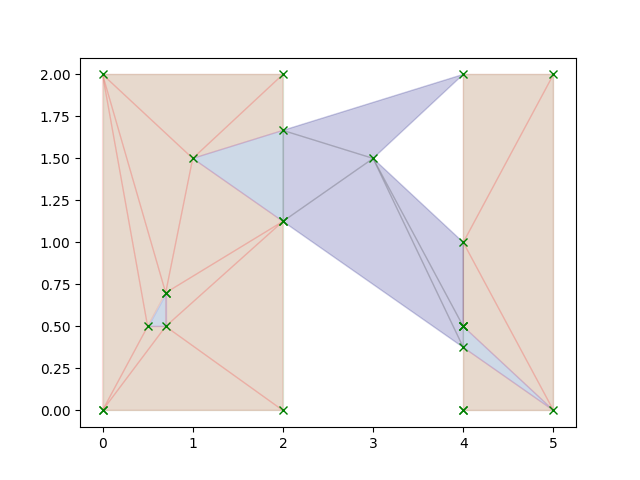

In [202]:
if __name__ == '__main__':
    _, axtestMerge = plt.subplots()

    meshexemple = MyMesh()

    poly1 = MultiPolygon([Polygon([(0, 0), (2, 0), (2, 2), (0, 2)]), Polygon([(4,0), (5, 0), (5, 2), (4, 2)])])
    poly2 = MultiPolygon([Polygon([(1, 1.5), (5, 0), (4, 0.5), (4, 1), (3, 1.5), (4, 2)]), Polygon([(0.5, 0.5), (0.7, 0.5), (0.7, 0.7)])])


    draw_multipolygon(poly1, axtestMerge, color='green', alpha=0.1)
    draw_multipolygon(poly2, axtestMerge, color='blue', alpha=0.1)
    mergetwoslices(meshexemple, poly1, poly2, 60.5, visualize=axtestMerge)
    print(meshexemple.vertices)
    print(meshexemple.faces)
    plt.show()


Real example with the layers 60 and 61.

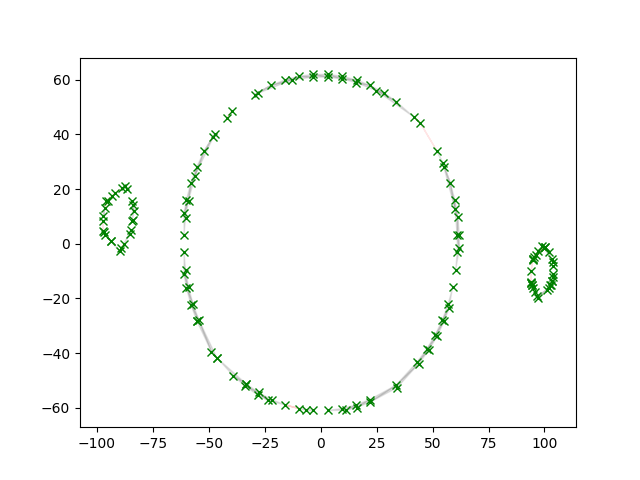

In [203]:
if __name__ == '__main__':
    _, axdebug = plt.subplots()
    layer = 60
    poly1 = multipolygons[layer]
    poly2 = multipolygons[layer+1]
    draw_multipolygon(poly1, axtestMerge, color='green', alpha=0.1)
    draw_multipolygon(poly2, axtestMerge, color='blue', alpha=0.1)
    mergetwoslices(meshexemple, poly1, poly2, 60.5, visualize=axdebug)
    plt.show()

In [204]:
def layerstomesh(layers):
    '''Given the layers in the form of multipolygons, returns the reconstructed
    mesh'''
    res = MyMesh()
    previouspoints = []
    for i in range(-1, config.height):
        poly1 = MultiPolygon() if (i == -1) else layers[i]
        poly2 = MultiPolygon() if (i == config.height - 1) else layers[i + 1]
        y = config.height / 2 - i - 0.5

        #build side faces
        thosepoints = mergetwoslices(res, poly1, poly2, y)
        res.addFaceToFace(previouspoints, thosepoints, poly1)
        previouspoints = thosepoints
    return res

In [205]:
if __name__ == '__main__':
    mesh = layerstomesh(multipolygons)
    mesh.plot()

In [ ]:
def shadowToObj(config, shadows):
    layers = [intersection_multipoly(processLayer(shadows, i)) for i in range(config.height)]
    return layerstomesh(layers)